<a href="https://colab.research.google.com/github/clobos/ECO5056_2026/blob/main/Aula_02_Aprendizado_Supervisionado_Ecologia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 02 — Aprendizado Supervisionado em Ecologia
**Base real:** caranguejos *Leptograpsus*. **Pergunta:** medidas morfológicas discriminam quatro grupos espécie/cor × sexo?

A base é pequena, balanceada (50 por grupo) e apropriada para comparar algoritmos no mesmo esquema de validação.

## 1. Objetivos da aula
Comparar regressão logística, árvore, Random Forest e SVM; compreender padronização, hiperparâmetros e métricas multiclasse; discutir por que o modelo mais complexo pode não ser o melhor.

## 2. Pergunta ecológica
**Quanto sinal de identidade de grupo (forma azul/laranja × sexo) está contido em cinco medidas do corpo?** A unidade amostral é o indivíduo.

## 3. Fonte dos dados
Campbell, N. A. & Mahon, R. J. (1974). A multivariate study of variation in two species of rock crab of genus *Leptograpsus*. Australian Journal of Zoology 22, 417–425. Distribuída no pacote MASS/R.

## 4. Importação das bibliotecas

In [1]:
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, sklearn
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import ConfusionMatrixDisplay, balanced_accuracy_score, f1_score
np.random.seed(42)
print("scikit-learn",sklearn.__version__)

scikit-learn 1.6.1


## 5. Download ou carregamento dos dados

In [2]:
URL="https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/MASS/crabs.csv"
try:
    dados=pd.read_csv(URL); fonte_execucao="URL pública"
except Exception:
    dados=pd.read_csv(Path("/mnt/data/crabs.csv")); fonte_execucao="fallback local de QA"
print(fonte_execucao,dados.shape)

URL pública (200, 9)


## 6. Conhecendo a base

In [3]:
dados["grupo"] = dados["sp"].astype(str)+"_"+dados["sex"].astype(str)
features=["FL","RW","CL","CW","BD"]
display(dados.head())
print(dados["grupo"].value_counts())
print(dados[features].describe().round(2))

,rownames,sp,sex,index,FL,RW,CL,CW,BD,grupo
0,1,B,M,1,8.1,6.7,16.1,19.0,7.0,B_M
1,2,B,M,2,8.8,7.7,18.1,20.8,7.4,B_M
2,3,B,M,3,9.2,7.8,19.0,22.4,7.7,B_M
3,4,B,M,4,9.6,7.9,20.1,23.1,8.2,B_M
4,5,B,M,5,9.8,8.0,20.3,23.0,8.2,B_M


grupo
B_M    50
B_F    50
O_M    50
O_F    50
Name: count, dtype: int64
           FL      RW      CL      CW      BD
count  200.00  200.00  200.00  200.00  200.00
mean    15.58   12.74   32.11   36.41   14.03
std      3.50    2.57    7.12    7.87    3.42
min      7.20    6.50   14.70   17.10    6.10
25%     12.90   11.00   27.28   31.50   11.40
50%     15.55   12.80   32.10   36.80   13.90
75%     18.05   14.30   37.22   42.00   16.60
max     23.10   20.20   47.60   54.60   21.60


## 7. Análise exploratória

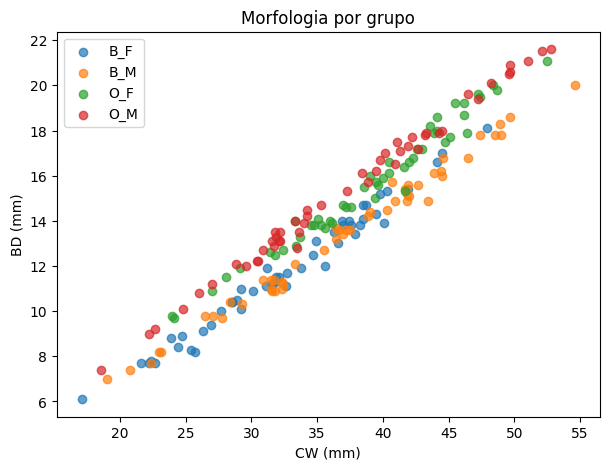

In [4]:
fig,ax=plt.subplots(figsize=(7,5))
for g,s in dados.groupby("grupo"):
    ax.scatter(s["CW"],s["BD"],label=g,alpha=.7)
ax.set(xlabel="CW (mm)",ylabel="BD (mm)",title="Morfologia por grupo"); ax.legend(); plt.show()

## 8. Preparação dos dados
Todos os modelos recebem os mesmos `X`, `y` e as mesmas cinco partições estratificadas. SVM e regressão logística são padronizados em `Pipeline`; árvores não exigem padronização.

In [5]:
X=dados[features]; y=dados["grupo"]
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

## 9. Construção do modelo

In [6]:
modelos={
"Regressão logística":Pipeline([("scale",StandardScaler()),("model",LogisticRegression(max_iter=5000,random_state=42))]),
"Árvore":DecisionTreeClassifier(max_depth=4,min_samples_leaf=3,random_state=42),
"Random Forest":RandomForestClassifier(n_estimators=400,min_samples_leaf=2,class_weight="balanced",random_state=42,n_jobs=-1),
"SVM RBF":Pipeline([("scale",StandardScaler()),("model",SVC(C=3,kernel="rbf",gamma="scale",random_state=42))])
}

## 10. Avaliação

In [7]:
linhas=[]
for nome,m in modelos.items():
    r=cross_validate(m,X,y,cv=cv,scoring={"accuracy":"accuracy","balanced_accuracy":"balanced_accuracy","f1_macro":"f1_macro"},n_jobs=-1)
    linhas.append([nome,r["test_accuracy"].mean(),r["test_balanced_accuracy"].mean(),r["test_f1_macro"].mean(),r["test_accuracy"].std()])
resultado=pd.DataFrame(linhas,columns=["modelo","accuracy","balanced_accuracy","f1_macro","sd_accuracy"]).sort_values("balanced_accuracy",ascending=False)
display(resultado.round(3))

,modelo,accuracy,balanced_accuracy,f1_macro,sd_accuracy
0,Regressão logística,0.925,0.925,0.925,0.016
3,SVM RBF,0.905,0.905,0.906,0.024
2,Random Forest,0.775,0.775,0.772,0.069
1,Árvore,0.580,0.580,0.565,0.058


## 11. Visualizações

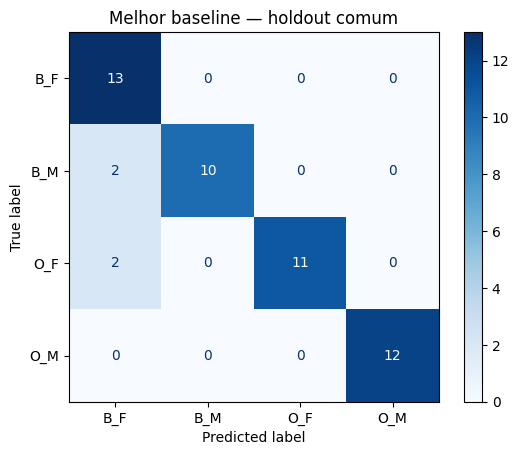

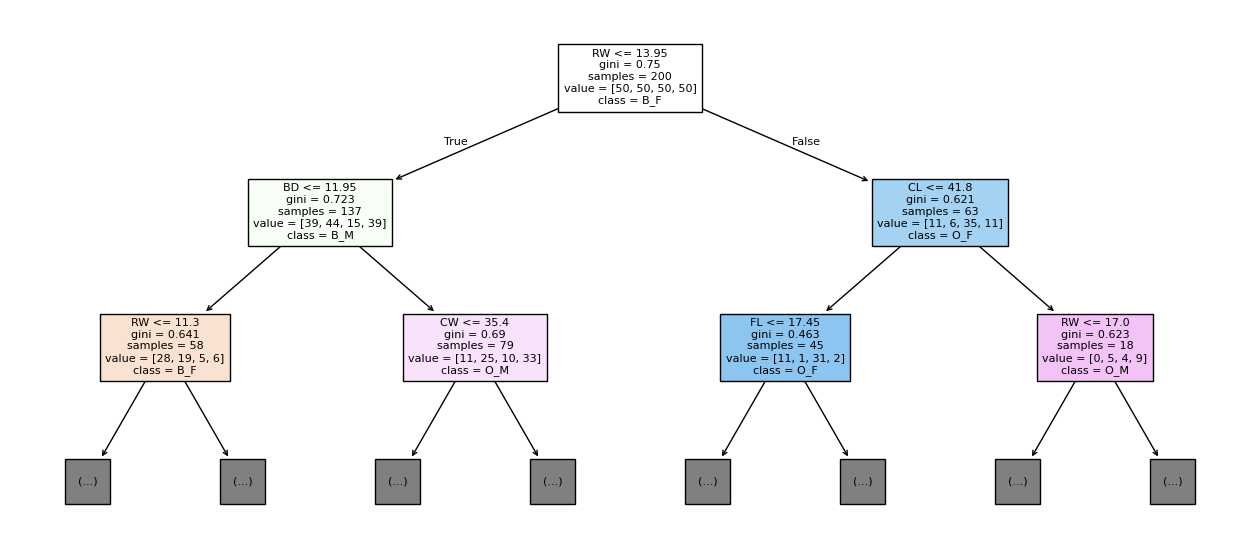

In [8]:
Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=.25,stratify=y,random_state=42)
best=modelos[resultado.iloc[0]["modelo"]]; best.fit(Xtr,ytr); pred=best.predict(Xte)
ConfusionMatrixDisplay.from_predictions(yte,pred,cmap="Blues"); plt.title("Melhor baseline — holdout comum"); plt.show()
# árvore didática
tree=modelos["Árvore"].fit(X,y)
plt.figure(figsize=(16,7)); plot_tree(tree,feature_names=features,class_names=tree.classes_,filled=True,max_depth=2,fontsize=8); plt.show()

## 12. Interpretação ecológica
A comparação deve ser feita pelas médias de validação cruzada, não por uma única execução. Se regressão logística/SVM superarem Random Forest, a conclusão correta é que fronteiras relativamente regulares no espaço morfométrico podem ser suficientes; não há prêmio científico por usar o algoritmo mais sofisticado.

## 13. Limitações
- Conjunto histórico e pequeno.
- `sp` representa duas formas/categorias usadas no dataset; não extrapole taxonomia além da fonte.
- Não há estrutura de local/tempo para testar transferência.
- Hiperparâmetros foram escolhidos para demonstração, sem *nested CV*.
- Para seleção final, ajuste deve ocorrer dentro de uma validação aninhada.

## 14. Exercícios
1. Varie `max_depth` da árvore e construa curva treino × validação.
2. Teste `C` e `gamma` do SVM em validação aninhada.
3. Transforme o problema em classificação binária de `sp` e compare métricas.
4. Use permutation importance no Random Forest e critique a interpretação causal.

## 15. Desafio para o estudante
Redija uma recomendação metodológica de uma página escolhendo um modelo para um estudo morfométrico novo. Sua justificativa deve considerar desempenho, interpretabilidade, tamanho amostral, estabilidade e plano de validação.
### Reprodutibilidade
Todos os procedimentos aleatórios usam semente 42. Ao adaptar o notebook, mantenha a separação entre dados de desenvolvimento e dados de avaliação e registre versões de bibliotecas e decisões analíticas.